In [1]:
import numpy as np

from src.resource_estimates.PPP_model import PPP_hamiltonian_simulation_resources, PPP_qpe_resources

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import matplotlib

In [2]:
figsz = (8,6)
font = {'size': 12}

matplotlib.rc('font', **font)

v, U = 1, 4
x = 0.01

Ls = [8, 12, 16, 20]
Ns = [2*L**2 for L in Ls]

label_color_map = {
    "2nd order": 'r',
    #"4th order": 'g',
    "augmented": 'b',
}

def dict_to_t_count(dct: dict) -> int:
    tc = 0
    if "t" in dct.keys():
        tc += dct["t"] 
        
    if "tdg" in dct.keys():
        tc += dct["tdg"] 
        
    if "toffoli" in dct.keys():
        tc += 4*dct["toffoli"]
    return tc


# Time evolution:

/home/aftkvantify/lie-algebra-trotterization/src/resource_estimates/rotation_synthesis.py:43: UserWarning: When synthesizing rotation into clifford plus T, this function does not compute the single-qubit clifford count due to arbitrary rotations.
  warnings.warn(


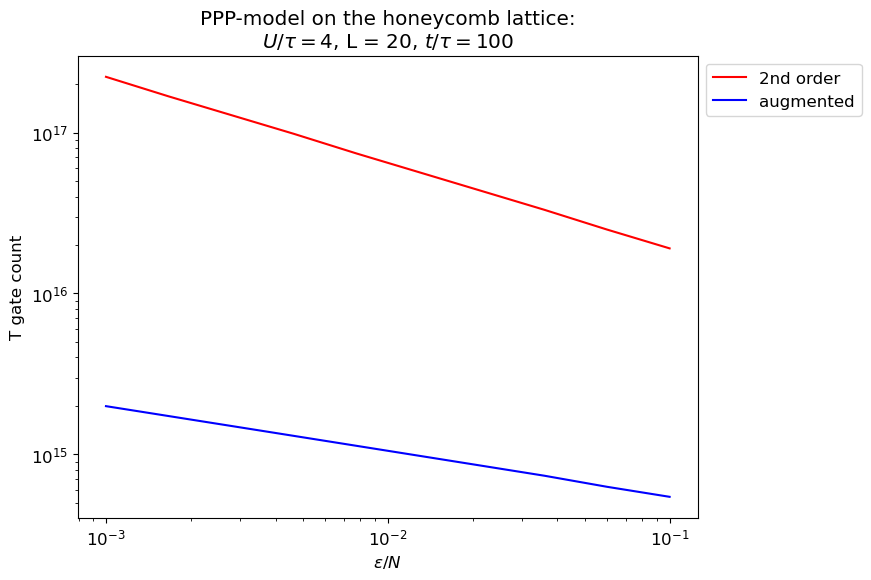

In [3]:
fig, ax = plt.subplots(figsize = figsz)
plt.subplots_adjust(hspace=0.05)
ax.set_ylabel('T gate count')
ax.set_xlabel(rf'$\varepsilon / N$')

time = 100
logeps = np.linspace(-3, -1, 10)
eps = np.pow(10, logeps)

ax.set_title(f"PPP-model on the honeycomb lattice:\n" + rf"$U/\tau = {U}$, L = {Ls[-1]}, $t/\tau = {time}$")

for lab, c in label_color_map.items():
    ax.plot([],[], color = c, label = lab)

ax.set_xscale('log')
ax.set_yscale('log')

ax.legend(loc = "upper left", bbox_to_anchor = (1,1))

for method, c in label_color_map.items():
    dcts = [
        PPP_hamiltonian_simulation_resources(
            U,
            v,
            Ls[-1],
            Ls[-1],
            time,
            e * Ns[-1],
            method,
            x=x
        ) for e in eps
    ]
    yt = [dict_to_t_count(dct) for dct in dcts]
    ax.plot(eps, yt, color = c)

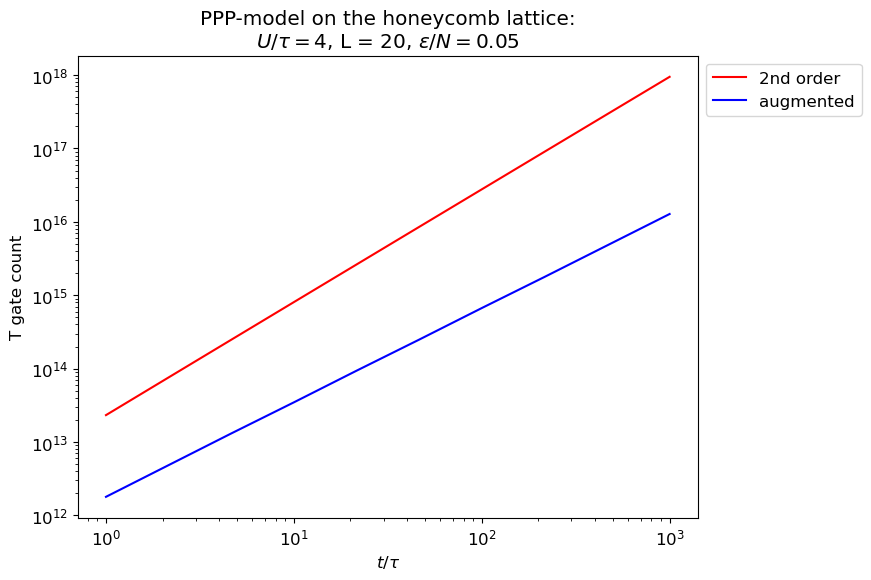

In [4]:
fig, ax = plt.subplots(figsize = figsz)
plt.subplots_adjust(hspace=0.05)
ax.set_ylabel('T gate count')
ax.set_xlabel(rf'$ t / \tau$')

eps = 0.05
logts = np.linspace(0, 3, 10)
ts = np.pow(10, logts)

ax.set_title(f"PPP-model on the honeycomb lattice:\n" + rf"$U/\tau = {U}$, L = {Ls[-1]}, $\varepsilon/ N = {eps}$")

for lab, c in label_color_map.items():
    ax.plot([],[], color = c, label = lab)

ax.set_xscale('log')
ax.set_yscale('log')

ax.legend(loc = "upper left", bbox_to_anchor = (1,1))

for method, c in label_color_map.items():
    dcts = [
        PPP_hamiltonian_simulation_resources(
            U,
            v,
            Ls[-1],
            Ls[-1],
            t,
            eps * Ns[-1],
            method,
            x=x
        ) for t in ts
    ]
    yt = [dict_to_t_count(dct) for dct in dcts]
    ax.plot(ts, yt, color = c)

# Quantum Phase Estimation

/home/aftkvantify/lie-algebra-trotterization/src/resource_estimates/quantum_phase_estimation.py:134: RuntimeWarning: divide by zero encountered in scalar divide
  return bit_precision_constant/(t*target_error - res)


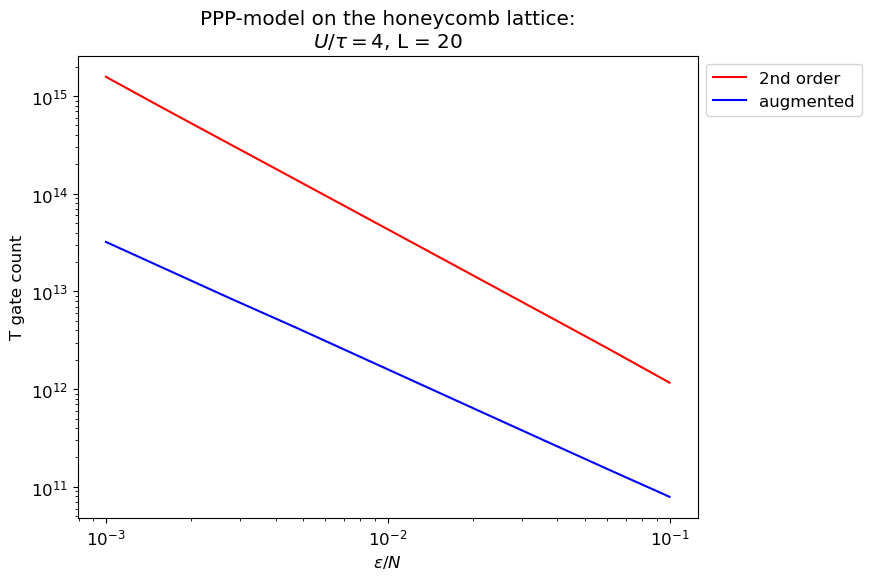

In [5]:
fig, ax = plt.subplots(figsize = figsz)
plt.subplots_adjust(hspace=0.05)
ax.set_ylabel('T gate count')
ax.set_xlabel(rf'$\varepsilon / N$')

time = 100
logeps = np.linspace(-3, -1, 10)
eps = np.pow(10, logeps)

ax.set_title(f"PPP-model on the honeycomb lattice:\n" + rf"$U/\tau = {U}$, L = {Ls[-1]}")

for lab, c in label_color_map.items():
    ax.plot([],[], color = c, label = lab)

ax.set_xscale('log')
ax.set_yscale('log')

ax.legend(loc = "upper left", bbox_to_anchor = (1,1))

for method, c in label_color_map.items():
    dcts = [
        PPP_qpe_resources(
            U,
            v,
            Ls[-1],
            Ls[-1],
            e * Ns[-1],
            phase_estimation_algorithm="adaptive",
            algorithm=method,
            x=x
        ) for e in eps
    ]
    yt = [dict_to_t_count(dct) for dct in dcts]
    ax.plot(eps, yt, color = c)

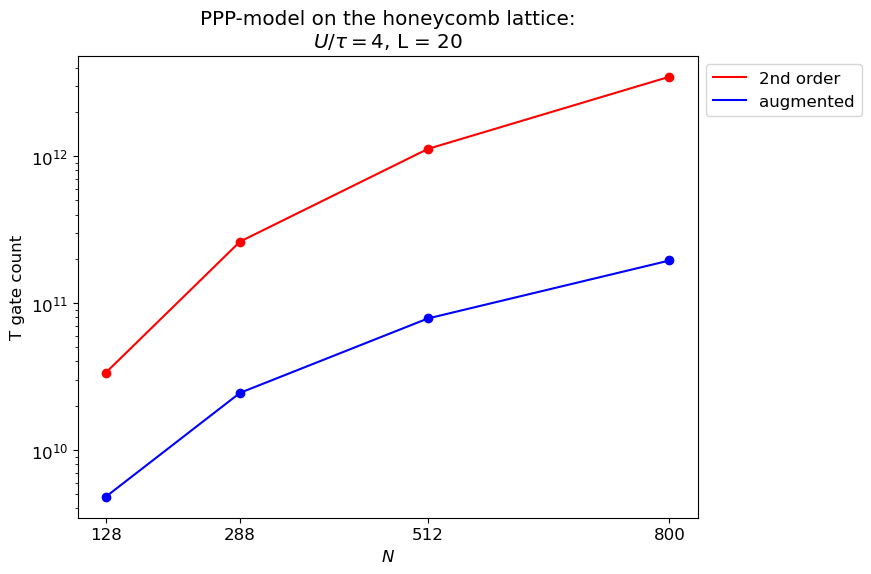

In [6]:
fig, ax = plt.subplots(figsize = figsz)
plt.subplots_adjust(hspace=0.05)
ax.set_ylabel('T gate count')
ax.set_xlabel(rf'$N$')

eps = 0.05

ax.set_title(f"PPP-model on the honeycomb lattice:\n" + rf"$U/\tau = {U}$, L = {Ls[-1]}")

for lab, c in label_color_map.items():
    ax.plot([],[], color = c, label = lab)

#ax.set_xscale('log')
ax.set_yscale('log')

ax.legend(loc = "upper left", bbox_to_anchor = (1,1))

for method, c in label_color_map.items():
    dcts = [
        PPP_qpe_resources(
            U,
            v,
            L,
            L,
            eps * N,
            phase_estimation_algorithm="adaptive",
            algorithm=method,
            x=x
        ) for L, N in zip(Ls, Ns)
    ]
    yt = [dict_to_t_count(dct) for dct in dcts]
    ax.scatter(Ns, yt, color = c)
    ax.plot(Ns, yt, color = c)

ax.set_xticks(Ns)
ax.xaxis.set_minor_locator(ticker.NullLocator()) # fix weird xticker issue